In [2]:
import cobra 
from thermo_flux.io import load_excel as ex
import thermo_flux
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/nathan/PhD/04.Computational/202601_13C/3_src/')
import analysis.io_func as io_func
import seaborn as sns

## compare tfba predictions + with metabolome data constraints vs standard predefined direction fba
we will predict at GUR measured in chemostat cultures of Vemuri 2006 (https://doi.org/10.1128/AEM.72.5.3653-3661.2006)

In [3]:
PLOTTING_DATA_FOLDER='data_forplotting/'
DATA='datafiles/'
FOLDER_PLOTS='Figures/'

In [4]:
ecolimodel_bigg=cobra.io.load_model('iJR904')

Set parameter Username
Set parameter LicenseID to value 2749904
Academic license - for non-commercial use only - expires 2026-12-04


In [5]:
data=f'{DATA}data_allC.xlsx'

df=pd.read_excel(data, index_col=(0,1),sheet_name='dvmeas',header=2)
df_vemuri = df[df.index.get_level_values(0).str.contains('Vemuri')]
df_vemuri
##then only keep non-overflow predictions , so drop vemuri 5,6,7
df_vemuri_resp=df_vemuri.drop(df_vemuri[df_vemuri.index.get_level_values(0).str.contains('Vemuri5|Vemuri6|Vemuri7')].index)
# df_vemuri_resp


In [6]:
## get the non long format
df_normal = df_vemuri_resp.set_index('dim3', append=True)['Value'].unstack('dim3')
# 
# df_normal
##or rather rxn as cols and mean as value 
df_mean = (
    df_vemuri_resp
    .loc[df_vemuri_resp['dim3'] == 'mean', 'Value']
    .unstack('dim2')
)
df_sd=(
    df_vemuri_resp
    .loc[df_vemuri_resp['dim3'] == 'sd', 'Value']
    .unstack('dim2')

)
df_mean.to_csv(f'{PLOTTING_DATA_FOLDER}/ecoli_vermuri_exfluxmeas.csv')

In [7]:
# from cobra.flux_analysis.loopless import loopless_solution

In [8]:
#reset ex bounds like o2 to -9999
def_bound=999999.0
for rxn in ecolimodel_bigg.boundary:
    if rxn.bounds[0]!=-def_bound and rxn.bounds[0]!=0:
        rxn.lower_bound=-def_bound
        print(rxn)
    if rxn.bounds[1]!=def_bound and rxn.bounds[1]!=0:
        rxn.upper_bound=def_bound
        print(rxn)


EX_glc__D_e: glc__D_e <-- 
EX_o2_e: o2_e <-- 


In [9]:
ex_data=df_mean.columns.to_list()
ex_flux_inbigg=['EX_co2_e','EX_glc__D_e','EX_o2_e','BIOMASS_Ecoli']
# ##loopless
standardfba_exflux=pd.DataFrame(index=ex_data)
# looplessfba_exflux=pd.DataFrame(index=ex_data)
j=0
standardglc_flux=[]
ecolimodel_bigg.reactions.get_by_id('EX_glc__D_e').bounds=(-500,500)
for i,row in df_mean.iterrows():
# try :
    bio=row['EX_glc']
    ecolimodel_bigg.reactions.get_by_id('EX_glc__D_e').bounds=(bio,bio)
    nominal=ecolimodel_bigg.optimize()
    standardfba_exflux[j]=nominal.to_frame().loc[ex_flux_inbigg,'fluxes'].values
    ###loopless returns exatcly same ex fluxes
    # loopless=loopless_solution(ecolimodel_bigg,nominal)
    # looplessfba_exflux[j]=loopless.to_frame().loc[ex_flux_inbigg,'fluxes'].values
# except Exception as e:
    # print(e)
    # pass
    j+=1

read tfba ex flxues prediction done in notebook 1a

In [10]:
tfba_exflux=pd.read_csv(f'{PLOTTING_DATA_FOLDER}ecoli_tfbapred_vermuriconds.csv',index_col=0)
standardfba_exflux

,0,1,2,3
EX_co2,2.865792,3.913553,5.858195,8.280360
EX_glc,-0.684000,-1.209000,-2.166000,-3.358000
EX_o2,-2.805907,-3.751994,-5.512978,-7.706387
biomass,0.029866,0.080572,0.172166,0.286251


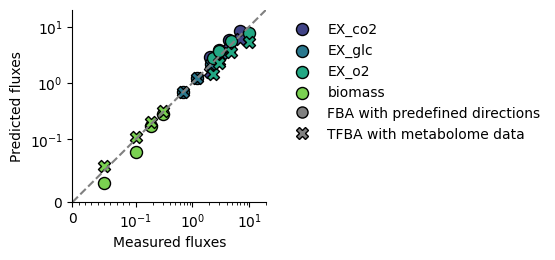

In [11]:
### scatter plot : x = measured fluxes, y = predicted fluxes with two different markers for standard and tfba pred
# x=
from matplotlib.lines import Line2D

fig,ax=plt.subplots(figsize=(2.5,2.5))


vircols=sns.color_palette('viridis',n_colors=len(ex_data))
for rxn,color in zip(ex_data,vircols):
    x=abs(df_mean[rxn])
    yfba=abs(standardfba_exflux.loc[rxn]) #if rxn not in ['o2_EX'] else -ex_flux_df.loc[rxn]
    ax.scatter(x,yfba,s=75,edgecolor='black',color=color,label=rxn)
    ##add scatter for loopless
    ytfba=abs(tfba_exflux.loc[rxn])
    ax.scatter(x,ytfba,s=75,edgecolor='black', marker='X',color=color)

ax.plot([0,1],[0,1],transform=ax.transAxes,color='grey',linestyle='--'  )
ax.set_xlim(0,20)
ax.set_ylim(0,20)
# ax.set_xticks([0,15])
# ax.set_yticks([0,15])
ax.set_xlabel('Measured fluxes')
ax.set_ylabel('Predicted fluxes')
ax.set_xscale('symlog',linthresh=0.1)
ax.set_yscale('symlog',linthresh=0.1)

#legend
# custom legend entries
fba_handle = Line2D(
    [], [], 
    marker='o',
    linestyle='None',
    markersize=8,
    markeredgecolor='black',
    markerfacecolor='gray',
    label='FBA with predefined directions'
)

tfba_handle = Line2D(
    [], [], 
    marker='X',
    linestyle='None',
    markersize=8,
    markeredgecolor='black',
    markerfacecolor='gray',
    label='TFBA with metabolome data'
)

# get existing handles (reaction colors)
handles, labels = ax.get_legend_handles_labels()

# append marker legend
handles += [fba_handle, tfba_handle]

ax.legend(
    handles=handles,
    frameon=False,
    bbox_to_anchor=(1.05, 1)
)

ax.xaxis.set_minor_locator(io_func.MinorSymLogLocator(1e-1)) 
ax.set_xticks([0,0.1,1,10])

##remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
##save
# plt.savefig(f'{FOLDER_PLOTS}ecoli-scatter_tfba_vs_fba_vemuriconds.png',dpi=300,bbox_inches='tight')
# plt.savefig(f'{FOLDER_PLOTS}ecoli-scatter_tfba_vs_fba_vemuriconds.svg',dpi=300,bbox_inches='tight')



### succinate condition 

In [12]:
## get jose df dataa
df_josedata=pd.read_csv(f'{DATA}allPhysioData_formatted_forGSM_20230831.csv',index_col=(0,1))
##and get the mean df like beofre 
df_wide = df_josedata["mean"].unstack("rxn")
df_wide

rxn,EX_ac,EX_ala-L,EX_arg-L,EX_asn-L,EX_co2,EX_for,EX_fru,EX_fum,EX_gal,EX_glc,...,EX_mal-L,EX_man,EX_o2,EX_oro,EX_pro-L,EX_pyr,EX_succ,EX_thr-L,EX_val-L,biomass_EX
cond,,,,,,,,,,,,,,,,,,,,,
WT-Ace_I,-16.522792,NaN,NaN,NaN,15.665613,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-15.953408,0.090739,NaN,NaN,NaN,NaN,NaN,0.300368
WT-Fruc_I,2.853784,NaN,NaN,NaN,13.477301,NaN,-9.279685,NaN,NaN,NaN,...,NaN,NaN,-14.499522,0.250842,NaN,NaN,NaN,NaN,NaN,0.573112
WT-Fum_I,NaN,NaN,NaN,NaN,21.509369,NaN,NaN,-16.058107,NaN,NaN,...,NaN,NaN,-16.243617,0.251195,NaN,NaN,1.361891,NaN,NaN,0.423250
WT-Gal_I,3.715879,NaN,NaN,NaN,12.448898,NaN,NaN,NaN,-7.850581,NaN,...,NaN,NaN,-16.289946,0.278946,NaN,NaN,NaN,NaN,NaN,0.452581
WT-Glc_I,10.836001,NaN,NaN,NaN,12.947187,NaN,NaN,NaN,NaN,-10.725831,...,NaN,NaN,-17.379448,0.308645,NaN,NaN,NaN,NaN,NaN,0.686360
WT-GlyCAA_II,3.677073,-0.414532,-0.418987,-3.368392,16.875233,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-19.609349,0.244916,-1.606596,NaN,NaN,-1.136941,0.479773,0.788060
WT-Glyc_I,0.998173,NaN,NaN,NaN,9.798941,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-16.250473,0.211855,NaN,NaN,NaN,NaN,NaN,0.510107
WT-Mann_I,0.720577,NaN,NaN,NaN,10.367553,0.609831,NaN,NaN,NaN,NaN,...,NaN,-6.42848,-10.840382,0.229803,NaN,NaN,NaN,NaN,NaN,0.474737
WT-Pyr_I,15.359468,NaN,NaN,NaN,31.102360,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-25.759419,0.141920,NaN,-37.058769,NaN,NaN,NaN,0.419570


In [13]:
ecolimodel_bigg.reactions.EX_glc__D_e.bounds=(0,500)
ecolimodel_bigg.reactions.EX_ac_e.bounds=(0,500)
ecolimodel_bigg.reactions.EX_succ_e.bounds=(-15.724824,-15.724824)
fbasol_df=ecolimodel_bigg.optimize().to_frame().loc[[r.id for r in ecolimodel_bigg.boundary]]
df_fba=fbasol_df[fbasol_df['fluxes']!=0]['fluxes']

In [34]:
df_fba.loc['biomass_EX']=ecolimodel_bigg.optimize().to_frame().loc['BIOMASS_Ecoli','fluxes']#BIOMASS_Ecoli
df_fba.index=[s.replace('_e','') for s in df_fba.index]


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [17]:
df_tfba=pd.read_csv(f'{PLOTTING_DATA_FOLDER}ecoli_succUR_exfluxes.csv',index_col=0)

plot

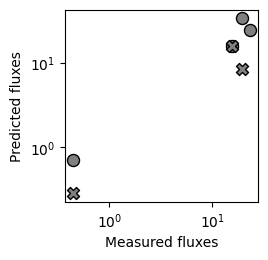

In [42]:
x=abs(df_wide.loc['WT-Succ_I'].dropna())
fig,ax=plt.subplots(figsize=(2.5,2.5))

common_mets=x.index.intersection(df_fba.index)
ax.scatter(x.loc[common_mets],abs(df_fba.loc[common_mets]),s=75,edgecolor='black', marker='o',color='gray')

common_mets_t=x.index.intersection(df_tfba.index)
ax.scatter(x.loc[common_mets_t],abs(df_tfba.loc[common_mets_t]),s=75,edgecolor='black', marker='X',color='gray')
# ax.plot([0,1],[0,1],transform=ax.transAxes,color='grey',linestyle='--'  )
# ax.set_xlim(0,20)
# ax.set_ylim(0,20)
# ax.set_xticks([0,15])
# ax.set_yticks([0,15])
ax.set_xlabel('Measured fluxes')
ax.set_ylabel('Predicted fluxes')
ax.set_xscale('symlog',linthresh=0.1)
ax.set_yscale('symlog',linthresh=0.1)

In [40]:
df_fba.loc[common_mets],x

(EX_co2        33.810399
 EX_o2        -24.541117
 EX_succ      -15.724824
 biomass_EX     0.701632
 Name: fluxes, dtype: float64,
 rxn
 EX_co2        19.496834
 EX_fum         1.080316
 EX_mal-L       0.466308
 EX_o2        -23.066197
 EX_oro         0.286768
 EX_succ      -15.724824
 biomass_EX     0.447089
 Name: WT-Succ_I, dtype: float64)

rxn
EX_co2        19.496834
EX_fum         1.080316
EX_mal-L       0.466308
EX_o2        -23.066197
EX_oro         0.286768
EX_succ      -15.724824
biomass_EX     0.447089
Name: WT-Succ_I, dtype: float64